In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pickle
from scipy import stats

import covid19_inference.covid19_inference as cov19

# increase plt fontsize
plt.rcParams.update({'font.size': 20})

from matplotlib import lines, patches

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (aesara.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (aesara.configdefaults): g++ not detected!  Aesara will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set Aesara flags cxx to an empty string.
WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['viridis']

color_m_base = colormap(0.0)
color_m = colormap(0.1)
color_R = colormap(0.4)
color_del_m_R = colormap(0.5)
color_m_R = colormap(0.6)
color_m_obs = colormap(0.7)
color_m_ICU = colormap(0.8)
color_del_m_ICU = colormap(0.9)
color_ICU = colormap(1.0)

# Input data

## Mobility

In [3]:
path_mobility = "data\mobility\mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.week
#display(mobility_df)

C:\Users\iftek\AppData\Local\Temp\ipykernel_8832\4267931410.py:4: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  mobility_df["week"] = mobility_df.index.week


In [4]:
# get dates
mobility_dates = mobility_df.index.values
mobility_dates_2020 = mobility_dates[mobility_dates < np.datetime64('2020-12-24')]
mobility_dates_2020 = mobility_dates_2020[mobility_dates_2020 > np.datetime64('2020-03-15')]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64('2022-12-24')]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020):]

# get mobility data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_df_2022 = mobility_df.filter(items=mobility_dates_2022_shortened, axis=0)

In [5]:
mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()
mobility_data_2022 = mobility_df_2022["outOfHomeDuration"].to_xarray()

### Plot

Text(0, 0.5, 'Difference in out of home\nduration $m_{2022} - m_{2020}$ [h]')

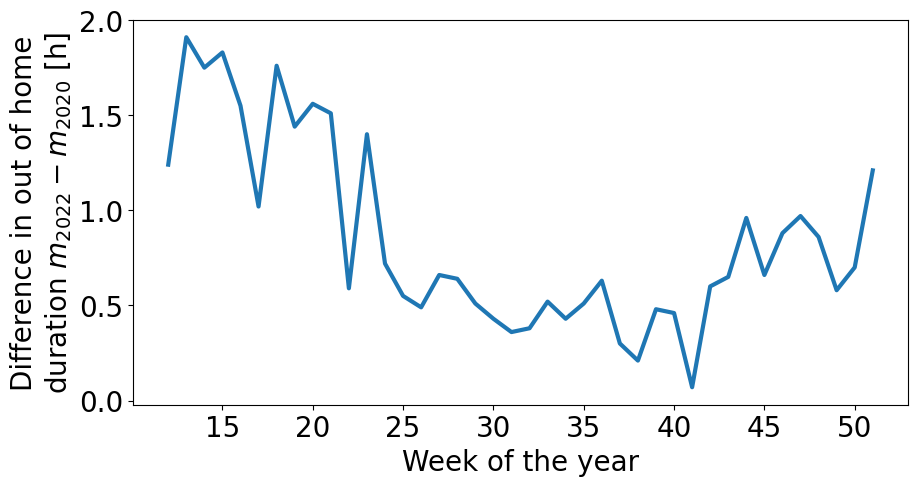

In [6]:
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"].values-mobility_df_2020["outOfHomeDuration"].values, linewidth=3)
#ax.legend()
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2022}} - m_{{2020}}$ [h]")

Text(0, 0.5, 'Difference in out of home\nduration $m_{2020} - m_{2022}$ [h]')

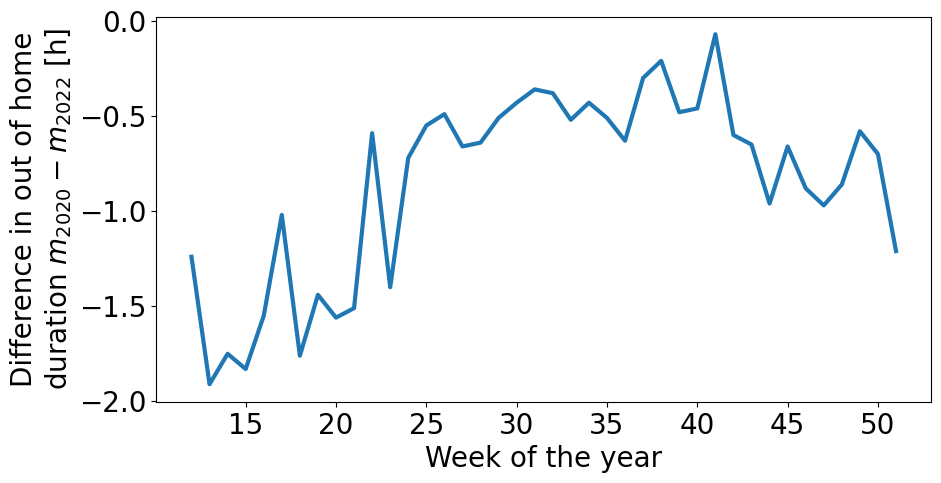

In [7]:
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mobility_df_2020["week"], mobility_df_2020["outOfHomeDuration"].values-mobility_df_2022["outOfHomeDuration"].values, linewidth=3)
#ax.legend()
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2020}} - m_{{2022}}$ [h]")

## Helper functions

In [6]:
def cut_off_before_monday(df):
    while df.index[0].dayofweek != 0:
        df = df[1:]
    return df

# weekly average placed on Sunday
def weekly_formatting(df_in, dates_in):
    df = cut_off_before_monday(df_in)
    df = df.resample('7D').mean()
    df.index = df.index + pd.Timedelta(days=6)
    return df.filter(items=dates_in, axis=0)

## Effective Reproduction Number

In [7]:
path_R = "data/R/Germany/R_eff_Germany.csv"
R_df = pd.read_csv(path_R, index_col=1, parse_dates=True)

In [8]:
# weekly average placed on Sunday
R_df_weekly_shortened = weekly_formatting(R_df, mobility_dates_2020)
R_data = R_df_weekly_shortened["R_eff median"].to_xarray()

# plot R data
#R_data.plot()

## Our World in Data

In [7]:
owid = cov19.data_retrieval.OWD()
owid.download_all_available_data()

INFO     [covid19_inference.covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from C:\Users\iftek\AppData\Local\Temp/covid19_data/, skipping download.


In [8]:
owid.data.columns

Index(['iso_code', 'continent', 'country', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       'total_vacc

### Hospitalisation

In [13]:
H_data = owid._filter(
    value = "weekly_hosp_admissions_per_million", 
    country="Germany", 
    )
H_data = weekly_formatting(H_data, mobility_dates_2020)
H_data = H_data.to_xarray()
H_data

<xarray.DataArray 'weekly_hosp_admissions_per_million' (date: 40)>
array([ 14.27014286,  42.141     ,  71.16657143,  66.51942857,
        47.80614286,  35.52157143,  21.77914286,  14.25657143,
        11.14485714,   7.423     ,   5.72485714,   4.102     ,
         3.47514286,   3.77971429,   3.85342857,   3.37057143,
         3.08471429,   3.374     ,   4.02828571,   4.26485714,
         4.83057143,   5.12542857,   5.34657143,   4.83057143,
         4.52885714,   5.134     ,   7.04942857,   8.82971429,
         9.949     ,  14.60442857,  23.14128571,  37.61214286,
        60.98457143,  78.934     ,  86.26814286,  96.51828571,
        99.75      , 104.82557143, 122.48685714, 144.78685714])
Coordinates:
  * date     (date) datetime64[ns] 2020-03-22 2020-03-29 ... 2020-12-20

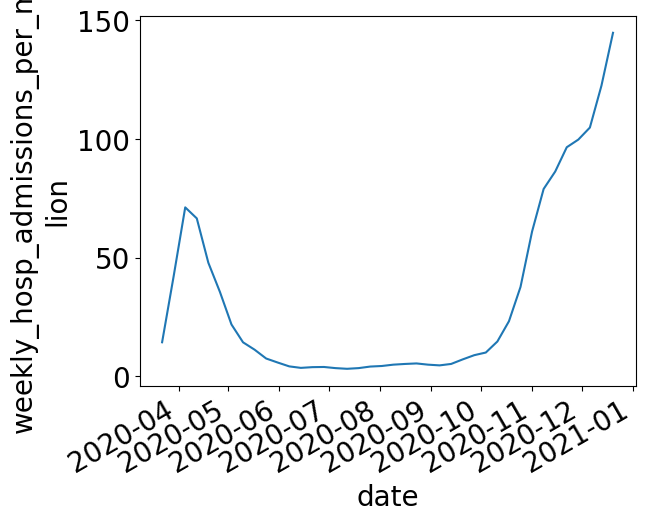

In [14]:
H_data.plot()

### ICU

In [9]:
ICU_data = owid._filter(
    value = "icu_patients_per_million", 
    country="Germany", 
    #data_begin=mobility_dates_2020[0], 
    #data_end=mobility_dates_2020[-1]
    )
ICU_data = weekly_formatting(ICU_data, mobility_dates_2020)
ICU_data = ICU_data.to_xarray()
#ICU_data

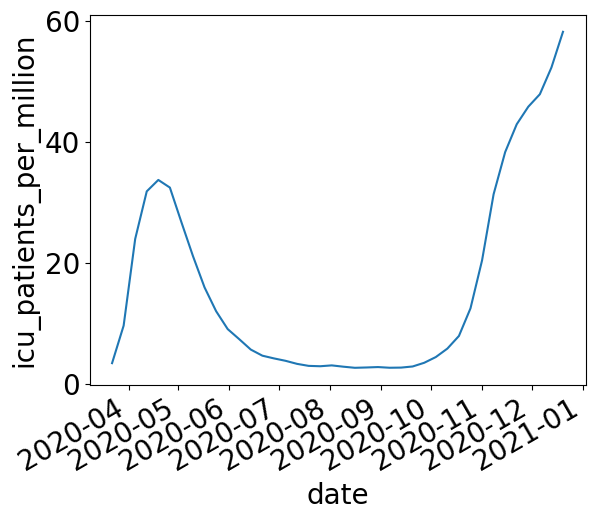

In [139]:
# plot ICU data
ICU_data.plot()

## Visualise and compare

(12.0, 51.0)

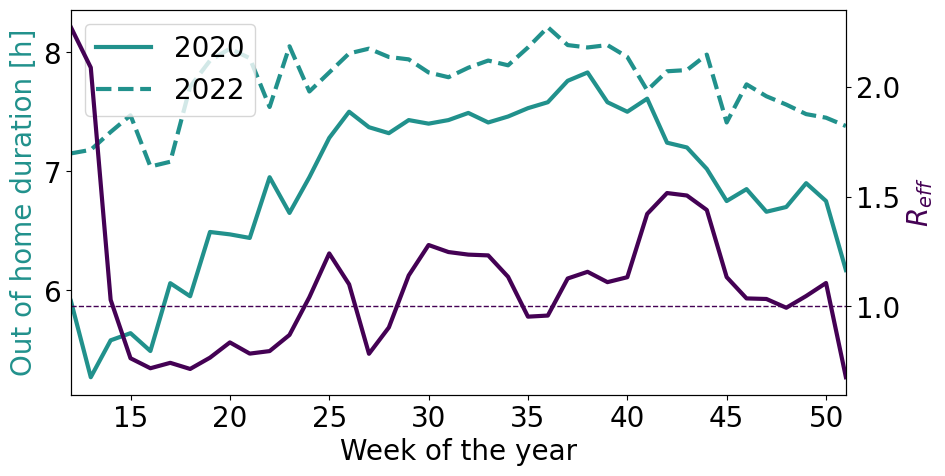

In [10]:
# plot mobility and R data
color_R = colormap(0)
color_m = colormap(0.5)

min_x = mobility_df_2020["week"].min()
max_x = mobility_df_2020["week"].max()

fig, ax = plt.subplots(figsize=(10, 5))
ax_R = ax.twinx()
ax.plot(mobility_df_2020["week"], mobility_df_2020["outOfHomeDuration"], label="2020", linewidth=3, color=color_m_R)
ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"], label="2022", linewidth=3, color=color_m_base, linestyle="--")
ax_R.plot(mobility_df_2020["week"], R_df_weekly_shortened["R_eff median"], linewidth=3, color=color_R)
ax_R.hlines(1, min_x, max_x, color=color_R, linestyle="--", linewidth=1)
ax.legend(loc="upper left")
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel("Out of home duration [h]", color=color_m)
ax_R.set_ylabel(f"$R_{{eff}}$", color=color_R)
ax.set_xlim(min_x, max_x)

# Bayesian Inference

## R model

In [12]:
n = R_data.shape[0]
with pm.Model() as R_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=1, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # NEED TO UNDERSTAND THE KERNEL BETTER
    R_model.sim_len = n
    R_model.diff_data_sim = 16
    risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )

    del_m_R = - a * risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # define likelihood
    m_R = pm.Deterministic("m_R", m_base_data + del_m_R)
    likelihood = pm.Normal('likelihood', mu=m_R, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [14]:
# inference
R_trace = pm.sample(model=R_model, draws=200, tune=200, cores=1, chains=4)
with R_model:
    pm.compute_log_likelihood(R_trace)

# Saving the results
tag = "R_model_test"	
# Save the trace
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(R_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.


## ICU model

In [10]:
n = ICU_data.shape[0]
with pm.Model() as ICU_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    icu_data = pm.ConstantData('ICU', ICU_data, dims=['time'])

    # define priors
    b = pm.Normal('b', mu=0.08, sigma=0.02)
    mu_ICU = pm.LogNormal('mu_ICU', mu=1, sigma=0.5)
    sigma_ICU = pm.LogNormal('sigma_ICU', mu=0.5, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # NEED TO UNDERSTAND THE KERNEL BETTER
    #R_model.shape_of_regions = 1
    ICU_model.sim_len = n
    ICU_model.diff_data_sim = 16
    risk = cov19.model.delay_cases(            
        cases=icu_data,
        delay_kernel="gamma",
        median_delay=mu_ICU,
        scale_delay=sigma_ICU,
        )

    del_m_ICU = - b * risk
    del_m_ICU = pm.Deterministic('del_m_ICU', del_m_ICU)

    # define likelihood
    m_ICU = pm.Deterministic("m_ICU", m_base_data + del_m_ICU)
    likelihood = pm.Normal('likelihood', mu=m_ICU, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [11]:
# inference
ICU_trace = pm.sample(model=ICU_model, draws=200, tune=200, cores=1, chains=4)

# Saving the results
# Save the trace
tag = "ICU_model_test"	
path = f"results/traces/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(ICU_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\multipledispatch\dispatcher.py:27: AmbiguityWarning: 
Ambiguities exist in dispatched function _unify

The following signatures may result in ambiguous behavior:
	[object, ConstrainedVar, Mapping], [ConstrainedVar, Var, Mapping]
	[ConstrainedVar, object, Mapping], [object, ConstrainedVar, Mapping]
	[ConstrainedVar, object, Mapping], [object, ConstrainedVar, Mapping]
	[ConstrainedVar, Var, Mapping], [object, ConstrainedVar, Mapping]


Consider making the following additions:

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)
  warn(warning_text(dispatcher.name, ambiguities), AmbiguityWarning)
Auto-assigning NUTS sampler...
INFO     [p

FileNotFoundError: [Errno 2] No such file or directory: 'results/traces/trace_ICU_model_test.pickle'

## Joint model

In [66]:
n = ICU_data.shape[0]
with pm.Model() as joint_model:
    joint_model.sim_len = n
    joint_model.diff_data_sim = 16

    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])
    icu_data = pm.ConstantData('ICU', ICU_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=0.8, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    b = pm.Normal('b', mu=0.05, sigma=0.01)
    mu_ICU = pm.LogNormal('mu_ICU', mu=0.8, sigma=0.2)
    sigma_ICU = pm.LogNormal('sigma_ICU', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # R model
    R_risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )
    del_m_R = - a * R_risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # ICU model
    ICU_risk = cov19.model.delay_cases(            
        cases=icu_data,
        delay_kernel="gamma",
        median_delay=mu_ICU,
        scale_delay=sigma_ICU,
        )
    del_m_ICU = - b * ICU_risk
    del_m_ICU = pm.Deterministic('del_m_ICU', del_m_ICU)

    # define likelihood
    m = pm.Deterministic("m", m_base_data + del_m_R + del_m_ICU)
    likelihood = pm.Normal('likelihood', mu=m, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


Delaying cases
before delayed cases
In delay kernel
Using gamma kernel
Used gamma kernel
Delaying cases
before delayed cases
In delay kernel
Using gamma kernel
Used gamma kernel


In [67]:
# inference
joint_trace = pm.sample(model=joint_model, draws=200, tune=200, cores=1, chains=1)

# ## Saving the results
# Save the trace.
tag = "joint_model_test"	
path = f"results/traces/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(joint_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
INFO     [pymc] Sequential sampling (1 chains in 1 job)
NUTS: [a, mu_R, sigma_R, b, mu_ICU, sigma_ICU, sigma]


Sampling 1 chain for 200 tune and 200 draw iterations (200 + 200 draws total) took 13237 seconds.
INFO     [pymc] Sampling 1 chain for 200 tune and 200 draw iterations (200 + 200 draws total) took 13237 seconds.
c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\arviz\data\base.py:221: UserWarning: More chains (200) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


# Results

In [17]:
def concatenate_chains_and_draws(xarray_in):
    array = np.array(xarray_in)
    return array.reshape(-1, array.shape[-1])

def plot_timeseries(ax_in, x_in, xarray_in, label_in, color_in):
    array = concatenate_chains_and_draws(xarray_in)
    ax_in.plot(x_in, np.median(array, axis=0), label=label_in, color=color_in, linewidth=3)
    ax_in.fill_between(
                x_in,
                np.percentile(array, q=3, axis=0),
                np.percentile(array, q=97, axis=0),
                alpha=0.5,
                color=color_in,
            )
    
def format_x_axis(ax_in, x_in, last=False):
    # choose number of x ticks
    n_xticks = 6
    # get x tick locations
    xticks = np.linspace(0, len(x_in)-1, n_xticks, dtype=int)
    # get x tick labels
    xticklabels = [x_in[i].strftime("%d %b") for i in xticks]
    # set x ticks
    ax_in.set_xticks([x_in[i]for i in xticks])
    # increase x tick length
    ax_in.tick_params(axis="x", length=10)
    if last:
        # set x tick labels
        ax_in.set_xticklabels(xticklabels)
        ax_in.set_xlabel("Year 2020")
    else:
        # set x tick labels
        ax_in.set_xticklabels([])
    # set x limits
    ax_in.set_xlim(x_in[0], x_in[-1])

In [18]:
# convert dates to datetime
dates = pd.to_datetime(mobility_dates_2020)

## R

In [32]:
az.summary(R_trace, var_names=["a", "mu_R", "sigma_R", "sigma"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.90,0.06,0.80,1.01,0.00,0.00,836.93,597.70,1.00
mu_R,1.59,0.31,1.13,2.15,0.02,0.02,338.15,156.37,1.02
sigma_R,1.44,0.13,1.20,1.69,0.00,0.00,829.28,641.65,1.00
sigma,0.47,0.05,0.38,0.58,0.00,0.00,574.84,621.83,1.01


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


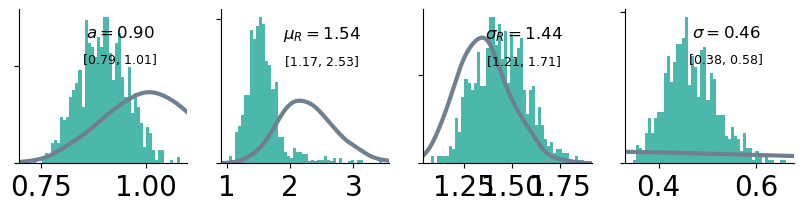

In [26]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(R_model, R_trace, 'a', dist_math='a', ax=axs[0])
cov19.plot.distribution(R_model, R_trace, 'mu_R', dist_math='\mu_R', ax=axs[1])
cov19.plot.distribution(R_model, R_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[2])
cov19.plot.distribution(R_model, R_trace, 'sigma', dist_math='\sigma', ax=axs[3])

fig.savefig(f"figures/{tag}_distributions.png", dpi=300, bbox_inches="tight")

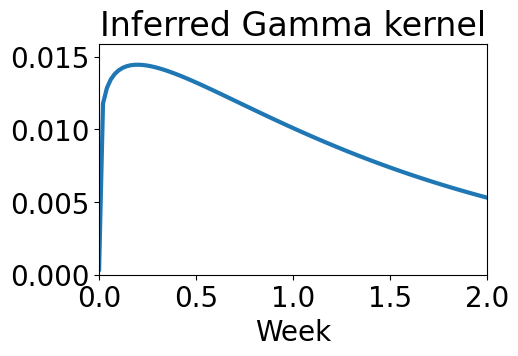

In [27]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(R_trace.posterior['mu_R']), sigma=np.median(R_trace.posterior['sigma_R'])).eval()
ax.plot(x, y, linewidth=3)
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max(y))
fig.savefig(f"figures/{tag}_gamma_kernel.png", dpi=300, bbox_inches="tight")

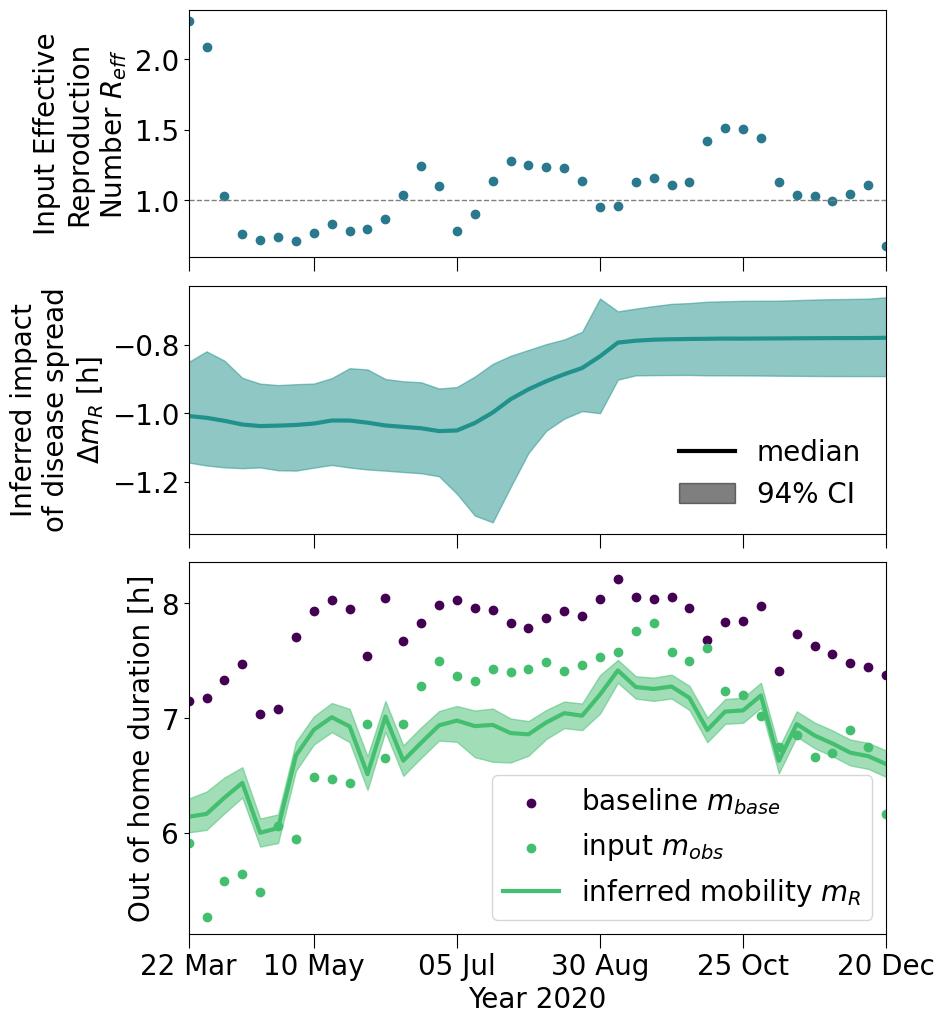

In [30]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, R_trace.constant_data["R_eff"], color=color_R)
ax.hlines(1, dates[0], dates[-1], linestyle="--", color="grey", linewidth=1)
ax.set_ylabel(f"Input Effective\nReproduction\nNumber $R_{{eff}}$")
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
plot_timeseries(ax, dates, R_trace.posterior['del_m_R'], "inferred impact of disease spread $\Delta m_R$", color_del_m_R)
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact\nof disease spread\n$\Delta m_R$ [h]")
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)

# lower plot
ax = axs[2]
ax.scatter(dates, R_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, R_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, R_trace.posterior['m_R'], "inferred mobility $m_R$", color_m_obs)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## ICU

In [22]:
az.summary(ICU_trace)

arviz - WARNING - Shape validation failed: input_shape: (1, 200), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,0.022,0.008,0.015,0.041,0.005,0.004,4.0,13.0,NaN
mu_ICU,5.128,6.515,0.732,17.565,4.282,3.521,3.0,13.0,NaN
sigma_ICU,1.754,0.189,1.459,2.157,0.033,0.023,32.0,93.0,NaN
sigma,0.706,0.113,0.496,0.871,0.035,0.026,11.0,41.0,NaN
del_m_ICU[0],-0.326,0.097,-0.462,-0.162,0.036,0.027,8.0,21.0,NaN
...,...,...,...,...,...,...,...,...,...
m_ICU[35],6.632,0.213,6.176,6.900,0.121,0.095,4.0,18.0,NaN
m_ICU[36],6.520,0.276,5.902,6.832,0.170,0.136,4.0,14.0,NaN
m_ICU[37],6.406,0.333,5.651,6.746,0.210,0.170,4.0,14.0,NaN
m_ICU[38],6.349,0.381,5.498,6.717,0.242,0.197,4.0,12.0,NaN


(0.0, 0.5011358613947319)

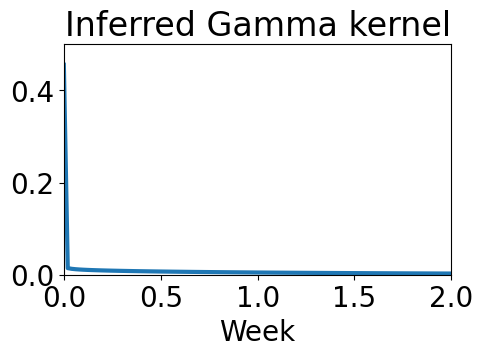

In [58]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(ICU_trace.posterior['mu_ICU']), sigma=np.median(ICU_trace.posterior['sigma_ICU'])).eval()
ax.plot(x, y, linewidth=3)
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max(y))

Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<AxesSubplot: >]

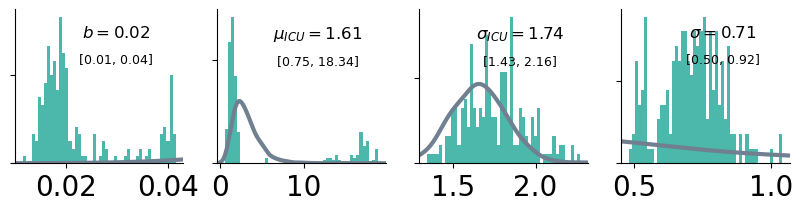

In [23]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(ICU_model, ICU_trace, 'b', dist_math='b', ax=axs[0])
cov19.plot.distribution(ICU_model, ICU_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1])
cov19.plot.distribution(ICU_model, ICU_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[2])
cov19.plot.distribution(ICU_model, ICU_trace, 'sigma', dist_math='\sigma', ax=axs[3])

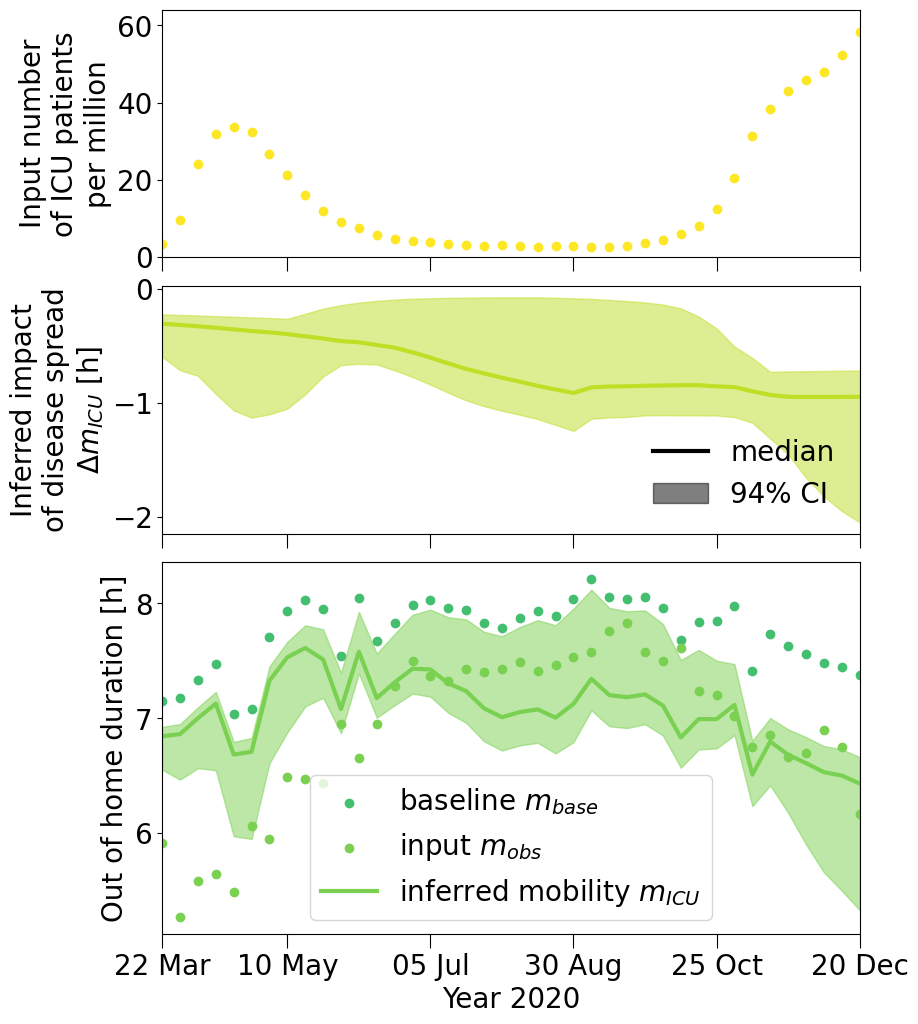

In [45]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, ICU_trace.constant_data["ICU"], color=color_ICU)
ax.set_ylabel(f"Input number\nof ICU patients\nper million")
ax.set_ylim(0, 1.1 * ICU_trace.constant_data["ICU"].max())
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
#ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"], label="2022", linewidth=3, color=color_m, linestyle="--")
plot_timeseries(ax, dates, ICU_trace.posterior['del_m_ICU'], "inferred impact of disease spread $\Delta m_ICU$", color_del_m_ICU)
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact\nof disease spread\n$\Delta m_{ICU}$ [h]")
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)

# lower plot
ax = axs[2]
ax.scatter(dates, ICU_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, ICU_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_ICU)
plot_timeseries(ax, dates, ICU_trace.posterior['m_ICU'], "inferred mobility $m_{ICU}$", color_m_ICU)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## Joint model

In [68]:
az.summary(joint_trace)

arviz - WARNING - Shape validation failed: input_shape: (1, 200), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.838,0.072,0.708,0.977,0.007,0.005,114.0,80.0,NaN
b,-0.000,0.003,-0.005,0.006,0.000,0.000,121.0,153.0,NaN
mu_R,1.632,0.304,1.204,2.237,0.037,0.027,88.0,94.0,NaN
sigma_R,1.455,0.139,1.181,1.706,0.011,0.008,155.0,127.0,NaN
mu_ICU,2.330,0.426,1.704,3.208,0.039,0.028,121.0,76.0,NaN
...,...,...,...,...,...,...,...,...,...
m_R[35],6.923,0.123,6.671,7.139,0.009,0.006,186.0,184.0,NaN
m_R[36],6.854,0.123,6.622,7.090,0.009,0.006,186.0,184.0,NaN
m_R[37],6.774,0.123,6.542,7.005,0.009,0.006,187.0,184.0,NaN
m_R[38],6.745,0.123,6.509,6.960,0.009,0.006,190.0,184.0,NaN


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<AxesSubplot: >]

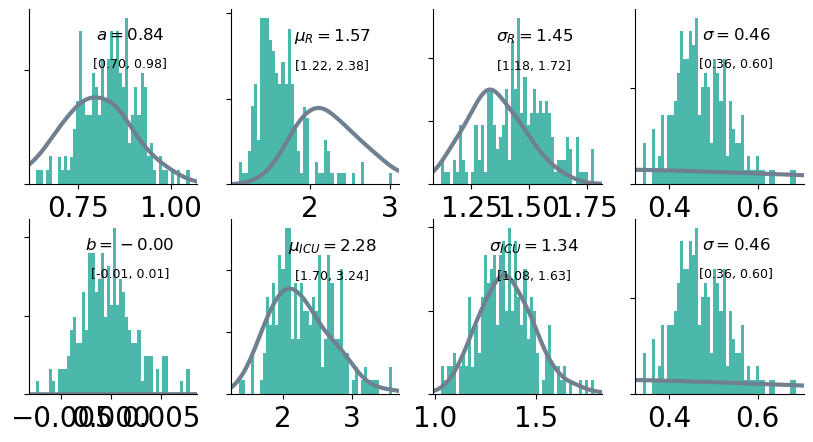

In [72]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(joint_model, joint_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(joint_model, joint_trace, 'b', dist_math='b', ax=axs[1,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[1,2])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

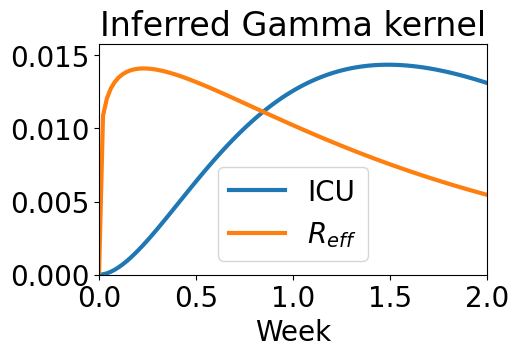

In [75]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(joint_trace.posterior['mu_ICU']), sigma=np.median(joint_trace.posterior['sigma_ICU'])).eval()
ax.plot(x, y, linewidth=3, label="ICU")
z = cov19.model._utility.tt_gamma(x, mu=np.median(joint_trace.posterior['mu_R']), sigma=np.median(joint_trace.posterior['sigma_R'])).eval()
ax.plot(x, z, linewidth=3, label="$R_{eff}$")
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max((np.max(y), np.max(z))))
ax.legend()

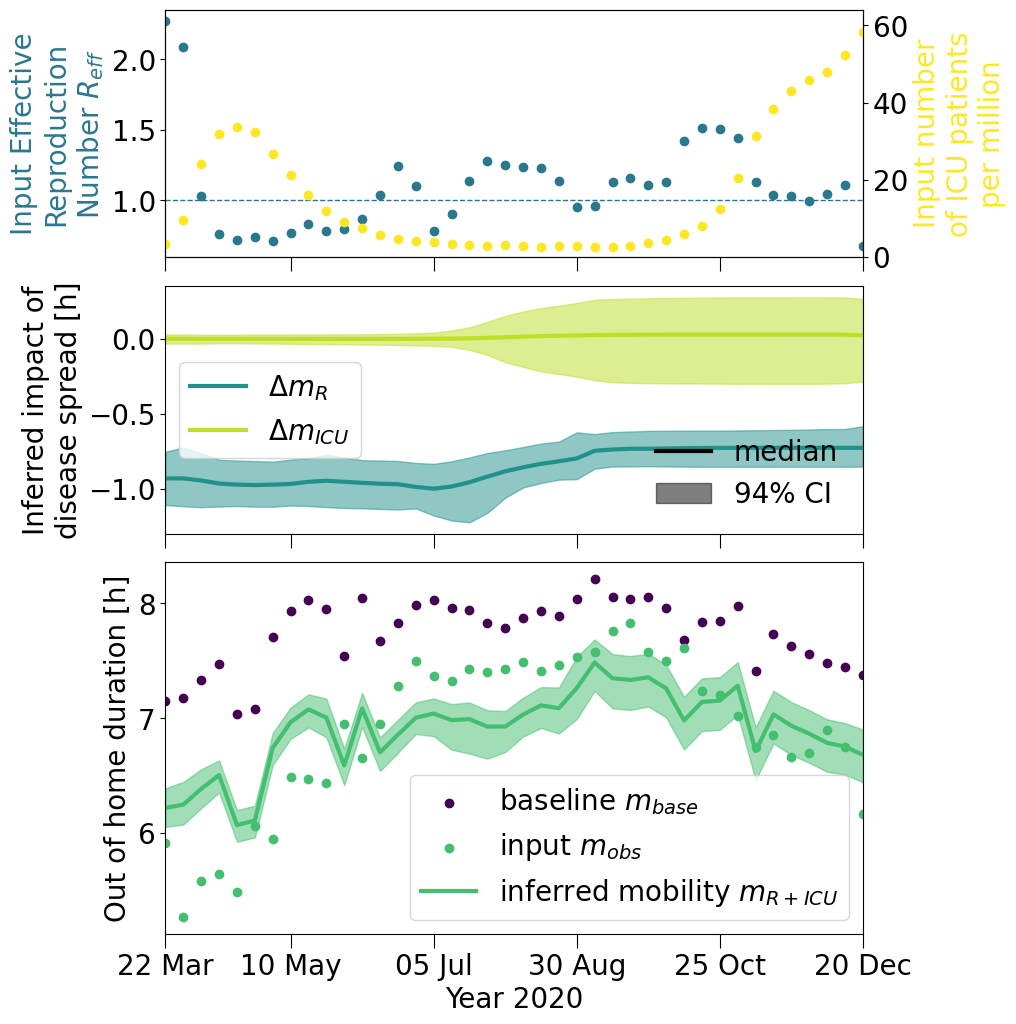

In [101]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, joint_trace.constant_data["R_eff"], color=color_R)
ax.hlines(1, dates[0], dates[-1], linestyle="--", color=color_R, linewidth=1)
ax.set_ylabel(f"Input Effective\nReproduction\nNumber $R_{{eff}}$", color=color_R)
ax_ICU = ax.twinx()
ax_ICU.scatter(dates, joint_trace.constant_data["ICU"], color=color_ICU)
ax_ICU.set_ylabel(f"Input number\nof ICU patients\nper million", color=color_ICU)
ax_ICU.set_ylim(0, 1.1 * joint_trace.constant_data["ICU"].max())
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
plot_timeseries(ax, 
                dates, 
                joint_trace.posterior['del_m_R'], 
                color_in=color_del_m_R,
                label_in="$\Delta m_R$",
                )
plot_timeseries(ax, 
                dates, 
                joint_trace.posterior['del_m_ICU'], 
                color_in=color_del_m_ICU,
                label_in="$\Delta m_{ICU}$")
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact of\ndisease spread [h]")
legend1 = ax.legend()
ax.add_artist(legend1)
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend2 = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)
#ax.add_artist(legend2)

# lower plot
ax = axs[2]
ax.scatter(dates, joint_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, joint_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, joint_trace.posterior['m_R'], "inferred mobility $m_{R+ICU}$", color_m_obs)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## Comparison

In [121]:
with ICU_model:
    pm.compute_log_likelihood(ICU_trace)

In [118]:
with joint_model:
    pm.compute_log_likelihood(joint_trace)

In [119]:
with R_model:
    pm.compute_log_likelihood(R_trace)

In [123]:
az.compare({
    "joint": joint_trace, 
    "R": R_trace, 
    "ICU": ICU_trace
    }, ic="loo")

c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\arviz\stats\stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
R,0,-25.687391,1.222052,0.000000,1.000000e+00,2.981386,0.000000,True,log
joint,1,-26.992238,1.918132,1.304847,0.000000e+00,3.252088,1.036319,False,log
ICU,2,-44.891066,4.341676,19.203675,2.369216e-13,4.274091,2.943676,False,log


In [124]:
az.compare({
    "joint": joint_trace, 
    "R": R_trace, 
    "ICU": ICU_trace
    }, ic="waic")

c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\arviz\stats\stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
R,0,-25.678218,1.212880,0.000000,1.000000e+00,2.979624,0.000000,False,log
joint,1,-26.966004,1.891897,1.287786,0.000000e+00,3.251150,1.037045,False,log
ICU,2,-44.751248,4.201859,19.073030,2.219336e-12,4.254278,2.914575,True,log
